# <center> R. M. S. Titanic
---

## Background

Peristiwa Titanic merupakan salah satu kecelakaan terbesar dalam sejarah transportasi di dunia. Kejadian tersebut terjadi pada 15 April 1912 akibat dari kapal yang menabrak bongkahan es saat melakukan perjalanan dari Southampton ke New York City. Jumlah penumpang kapal tersebut sebanyak 2224 orang dengan lebih dari 1500 orang meninggal dunia. 

---

## To Understand

Menggunakan data penumpang yang tercatat kita dapat melihat sikap/sifat manusia pada waktu kritis penentuan antara hidup dan mati.

---

## To Determine

Sikap/sifat manusia dalam menghadapi situasi darurat ini akan berpengaruh terhadap kemungkinan manusia untuk bertahan hidup. Hal tersebut dapat dijelaskan dengan karakteristik penumpang yang terdapat dalam data. Didukung dengan menggunakan algoritma Machine Learning untuk melihat kecocokan karakteristik tersebut dengan prediksi kemungkinan manusia untuk bertahan hidup.

---

## Initial Hypothesis

1. Older people drowned more than people in the prime age
2. Passengers with financial benefit had a better chance of survival
3. Social norm such as "Woman and Children first" will take a role in the rescue process

---

## Dataset Titanic3

Deskripsi: 
Dataset ini didapatkan dari daftar penumpang Titanic yang diedit oleh Michael A. Findlay, dipublish secara original oleh Eaton & Haas (1994) Titanic: Triumph and Tragedy, Patrick Stephens Ltd. Kemudian ditambahkan oleh bantuan komunitas internet. File HTML originalnya dapat dilihat di Philip Hind (1999). 
Data titanic3 ini menjelaskan tentang status keselamat setiap penumpang Titanic. Data tersebut tidak memberikan informasi tentang awak kapal, namun berisi data umur estimasi dan sebenarnya untuk hampir 80% penumpang.

Pedagogical notes:
Dataset ini baik digunakan untuk mengajarkan fungsi dasar S-PLUS pada ranah Komputer Statistik dan Grafis. Selain itu berguna untuk mengajarkan binary logistic regression dan metode imputation baik single ataupun multiple. Selanjutnya kita dapat mengeksplore fungsi yang didefinisikan pada library Frank Harrell yang salah satunya mendemonstrasikan analisis binary logistic regression.

1. Data size

Terdiri dari 1309 instances, 14 attributes, and 1 class.

2. Attributes


- Passenger Class: terbagi kedalam tiga kategori yaitu 1 ~ Upper, 2 ~ middle dan 3 ~ lower. Data ini merepresentasikan socio-economic status (SES)
- Name 
- Sex
- Age: dinyatakan dalam tahun, bernilai fraksi jika kurang dari 1 tahun. Perkiraan usia juga dilakukan dengan format xx.5
- Number of Siblings/Spouse and Number of Parents/Children dengan penjabaran sebagai berikut:

Sibling: Brother, Sister, Stepbrother, or Stepsister
Spouse: Hubsban or Wife (mistresses dan fiancees diabaikan)
Parent: Mother or Father
Child: Son, Daughter, Stepson, or Stepdaughter

- Abroad
- Ticket Number
- Fare: dinyatakan dalam brithis pounds tahun 1912.
- Cabin: dikelompokan dari mulai A-G
- Port of Embarkation: ada tiga tempat keberangkatan yang dilalui Titanic sebelum tenggelam, yaitu C: Cherbourg, Q: Queenstown, S: Southampton
- Lifeboat
- Body Identification Number
- Home Destination.

3. Class

Kita akan menggolongkan penumpang berdasarkan status keselamatannya maka class yang diassign adalah survival status.

4. Missing values

Jumlah keseluruhan missing value sebesar 3855.

5. Data proportion

Termasuk kedalam imbalaced dataset dengan jumlah penumpang meninggal dunia 809 orang dan 500 orang selamat.

---

## Main Exploration and Processing

1. Determine the best attribute to classify the survival of the passengers.
2. Using k-fold cross validation splitting technique for modeling.
3. Compare the level accuracy of each prediction model. We use: Logistic Regression, Decision Tree and Random Forest.

---

## Suggested Data Processing based on Previous Study

1. Modified nominal columns to numeric for analysist
2. Drop attribute cabin, name, ticket, and embarked
3. Assign missing value of age based on average value of related title
4. Make new attribute named Children and Mother also suggested titles (ex. Dr, Col etc)
5. Grouping for attribute fare and cabin

---

## Data understanding and preparation

1. Data understanding

Melihat arti dan hubungan dari setiap attribute untuk menentukan pengolahan data lanjutan yang lebih baik.

2. Data preparation includes:


- Identify and fix incorrectness of data type assignment
- Identify and fix noise or inconsistent data
- Identify and fix missing values
- Identify and fix outliers
- Identify and fix imbalanced dataset

---

In [ ]:
# Import library

import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import sklearn as sk

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from nameparser import HumanName
from nameparser.config import CONSTANTS

from imblearn.over_sampling import RandomOverSampler
import collections as clc

from scipy import stats
from statistics import mean

Using TensorFlow backend.


In [ ]:
# Import dataset titanic3 lalu melihat karakteristik data

df = pd.read_excel('titanic3.xls')
df.head(10)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


## Exploratory Data Analysis

In [ ]:
df.shape

(1309, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
pclass       1309 non-null int64
survived     1309 non-null int64
name         1309 non-null object
sex          1309 non-null object
age          1046 non-null float64
sibsp        1309 non-null int64
parch        1309 non-null int64
ticket       1309 non-null object
fare         1308 non-null float64
cabin        295 non-null object
embarked     1307 non-null object
boat         486 non-null object
body         121 non-null float64
home.dest    745 non-null object
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [ ]:
# Melihat persentase missing value setiap attribut

print('Persentase missing value untuk attribute:')
for i in range(len(df.columns)):
    p = (df[df[df.columns[i]].isnull()].shape[0]/len(df))*100 
    print(i+1, df.columns[i], ':', '%.3f' % p)

Persentase missing value untuk attribute:
1 pclass : 0.000
2 survived : 0.000
3 name : 0.000
4 sex : 0.000
5 age : 20.092
6 sibsp : 0.000
7 parch : 0.000
8 ticket : 0.000
9 fare : 0.076
10 cabin : 77.464
11 embarked : 0.153
12 boat : 62.872
13 body : 90.756
14 home.dest : 43.086


In [ ]:
# Cara lain menggunakan pandas dataframe
# Menghitung jumlah missing value setiap attribute kemudian mengurutkannya
inst = df.isnull().sum().sort_values(ascending = False)
print(inst)

# Menghitung persentase missing value setiap attribute
p1 = df.isnull().sum()/df.isnull().count()*100
print(p1)

# Mengurutkan persentase setiap attribute
p2 = (round(p1, 3)).sort_values(ascending = False)
print(p2)

# Membuat data frame dari hasil pengolahan
missing_data = pd.concat([inst, p2], axis = 1, keys = ['Jumlah', '%'])

print('\n', 'Berikut urutan banyaknya missing value setiap attribute:')
missing_data

body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
ticket          0
parch           0
sibsp           0
sex             0
name            0
survived        0
pclass          0
dtype: int64
pclass        0.000000
survived      0.000000
name          0.000000
sex           0.000000
age          20.091673
sibsp         0.000000
parch         0.000000
ticket        0.000000
fare          0.076394
cabin        77.463713
embarked      0.152788
boat         62.872422
body         90.756303
home.dest    43.086325
dtype: float64
body         90.756
cabin        77.464
boat         62.872
home.dest    43.086
age          20.092
embarked      0.153
fare          0.076
ticket        0.000
parch         0.000
sibsp         0.000
sex           0.000
name          0.000
survived      0.000
pclass        0.000
dtype: float64

 Berikut urutan banyaknya missing value setiap attribute:


,Jumlah,%
body,1188,90.756
cabin,1014,77.464
boat,823,62.872
home.dest,564,43.086
age,263,20.092
embarked,2,0.153
fare,1,0.076
ticket,0,0.000
parch,0,0.000
sibsp,0,0.000


In [ ]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [ ]:
# Melihat value counts masing-masing attribute untuk menentukan apakah ada data dengan inputan yang aneh

for i in range(len(df.columns)):
    print('Value counts untuk attribute', df.columns[i], ':')
    print(df[df.columns[i]].value_counts(), '\n')

# Pada attribute nama, ditemukan dua nama yang sama. Ini perlu ditinjau lebih jauh apakah memang merujuk ke satu orang yang sama atau berbeda

Value counts untuk attribute pclass :
3    709
1    323
2    277
Name: pclass, dtype: int64 

Value counts untuk attribute survived :
0    809
1    500
Name: survived, dtype: int64 

Value counts untuk attribute name :
Kelly, Mr. James                                2
Connolly, Miss. Kate                            2
Dean, Master. Bertram Vere                      1
Harris, Mrs. Henry Birkhardt (Irene Wallach)    1
Harper, Mrs. Henry Sleeper (Myna Haxtun)        1
                                               ..
McCoy, Mr. Bernard                              1
Davison, Mr. Thomas Henry                       1
Nakid, Mrs. Said (Waika "Mary" Mowad)           1
Wenzel, Mr. Linhart                             1
Sharp, Mr. Percival James R                     1
Name: name, Length: 1307, dtype: int64 

Value counts untuk attribute sex :
male      843
female    466
Name: sex, dtype: int64 

Value counts untuk attribute age :
24.0000    47
22.0000    43
21.0000    41
30.0000    40
18.0000   

In [ ]:
dfd = df[df.duplicated('name')]
dfd

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
726,3,0,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,NaN,NaN,Ireland
925,3,0,"Kelly, Mr. James",male,44.0,0,0,363592,8.0500,NaN,S,NaN,NaN,NaN


In [ ]:
print(df.loc[925,:])
print(df.loc[924,:])
print(df.loc[725,:])
print(df.loc[726,:])

# Ternyata meskipun namanya sama tapi attribute lain memiliki perbedaan sehingga tidak dapat dikategorikan sebagai data noise

pclass                      3
survived                    0
name         Kelly, Mr. James
sex                      male
age                        44
sibsp                       0
parch                       0
ticket                 363592
fare                     8.05
cabin                     NaN
embarked                    S
boat                      NaN
body                      NaN
home.dest                 NaN
Name: 925, dtype: object
pclass                      3
survived                    0
name         Kelly, Mr. James
sex                      male
age                      34.5
sibsp                       0
parch                       0
ticket                 330911
fare                   7.8292
cabin                     NaN
embarked                    Q
boat                      NaN
body                       70
home.dest                 NaN
Name: 924, dtype: object
pclass                          3
survived                        1
name         Connolly, Miss. Kate
sex     

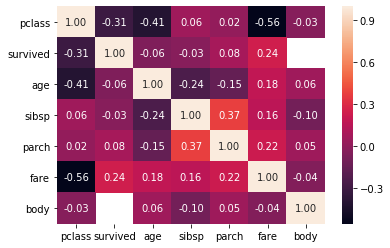

In [ ]:
corrd = df.corr(method = 'pearson')
sh = sb.heatmap(corrd, annot = True, fmt = '.2f')
fig = sh.get_figure()
fig.savefig('firstheatmap.png', dpi = 400)

In [ ]:
# Selanjutnya untuk menghitung outlier, kita dapat menggunakan cara statistik yang dipelajari sebelumnya yang dibuat menjadi sebuah program

for i in range(len(df.columns)):
    if (df[df.columns[i]].dtypes in ['int64', 'float64']):
        print('\nAttribute', df.columns[i], ':', df[df.columns[i]].dtypes)
        Q1 = df[df.columns[i]].quantile(0.25)
        print('Q1', Q1)
        Q3 = df[df.columns[i]].quantile(0.75)
        print('Q3', Q3)
        IQR = Q3 - Q1
        print('IQR', IQR)
        min = df[df.columns[i]].min()
        max = df[df.columns[i]].max()
        min_IQR = Q1-1.5*IQR
        max_IQR = Q3+1.5*IQR
        if (min<min_IQR):
            print('Low outlier is found. The min value is less than ' + str(min_IQR))
        if (max>max_IQR):
            print('High outlier is found. The min value is more than ' + str(max_IQR))


Attribute pclass : int64
Q1 2.0
Q3 3.0
IQR 1.0

Attribute survived : int64
Q1 0.0
Q3 1.0
IQR 1.0

Attribute age : float64
Q1 21.0
Q3 39.0
IQR 18.0
High outlier is found. The min value is more than 66.0

Attribute sibsp : int64
Q1 0.0
Q3 1.0
IQR 1.0
High outlier is found. The min value is more than 2.5

Attribute parch : int64
Q1 0.0
Q3 0.0
IQR 0.0
High outlier is found. The min value is more than 0.0

Attribute fare : float64
Q1 7.8958
Q3 31.275
IQR 23.379199999999997
High outlier is found. The min value is more than 66.34379999999999

Attribute body : float64
Q1 72.0
Q3 256.0
IQR 184.0


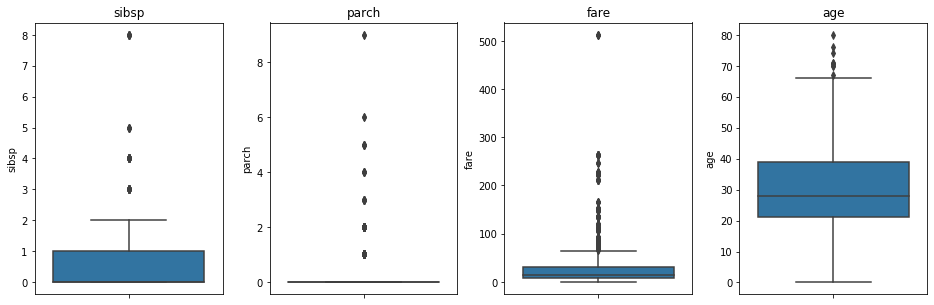

In [ ]:
# Distribusi outliers data

fig, axes = plt.subplots(1, 4, figsize = (16,5), facecolor = 'w', edgecolor = 'k')
fig.subplots_adjust(hspace = 0.5, wspace = 0.25)

sb.boxplot(y=df['sibsp'], ax = axes[0]).set_title('sibsp')
sb.boxplot(y=df['parch'], ax = axes[1]).set_title('parch')
sb.boxplot(y=df['fare'], ax = axes[2]).set_title('fare')
sb.boxplot(y=df['age'], ax = axes[3]).set_title('age')

fig.savefig('outliers.png', dpi = 400)

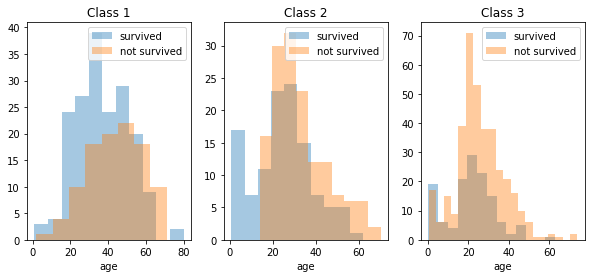

In [ ]:
# Age and survived

c1 = df[df['pclass'] == 1]
c2 = df[df['pclass'] == 2]
c3 = df[df['pclass'] == 3]

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (10, 4))

ax = sb.distplot(c1[c1['survived'] == 1].age.dropna(), label = 'survived', ax = axes[0], kde = False)
ax = sb.distplot(c1[c1['survived'] == 0].age.dropna(), label = 'not survived', ax = axes[0], kde = False)

ax.legend()
ax.set_title('Class 1')

ax = sb.distplot(c2[c2['survived'] == 1].age.dropna(), label = 'survived', ax = axes[1], kde = False)
ax = sb.distplot(c2[c2['survived'] == 0].age.dropna(), label = 'not survived', ax = axes[1], kde = False)

ax.legend()
ax.set_title('Class 2')

ax = sb.distplot(c3[c3['survived'] == 1].age.dropna(), label = 'survived', ax = axes[2], kde = False)
ax = sb.distplot(c3[c3['survived'] == 0].age.dropna(), label = 'not survived', ax = axes[2], kde = False)

ax.legend()
ax.set_title('Class 3')

fig.savefig('agepcsurv.png', dpi = 400)

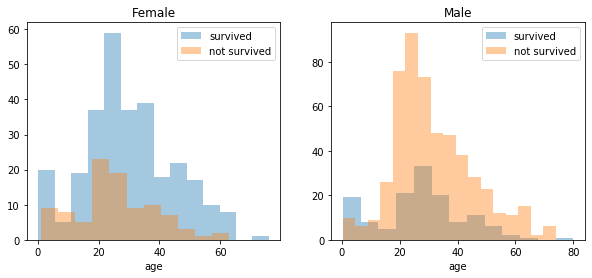

In [ ]:
# Age, Sex and survived

male = df[df['sex'] == 'male']
female = df[df['sex'] == 'female']

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

ax = sb.distplot(female[female['survived'] == 1].age.dropna(), label = 'survived', ax = axes[0], kde = False)
ax = sb.distplot(female[female['survived'] == 0].age.dropna(), label = 'not survived', ax = axes[0], kde = False)

ax.legend()
ax.set_title('Female')

ax = sb.distplot(male[male['survived'] == 1].age.dropna(), label = 'survived', ax = axes[1], kde = False)
ax = sb.distplot(male[male['survived'] == 0].age.dropna(), label = 'not survived', ax = axes[1], kde = False)

ax.legend()
ax.set_title('Male')

fig.savefig('agesexsurv.png', dpi = 400)

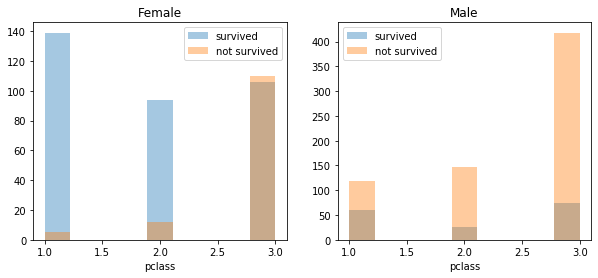

In [ ]:
# Pclass, sex and survived

male = df[df['sex'] == 'male']
female = df[df['sex'] == 'female']

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

ax = sb.distplot(female[female['survived'] == 1].pclass.dropna(), label = 'survived', bins = 9, ax = axes[0], kde = False)
ax = sb.distplot(female[female['survived'] == 0].pclass.dropna(), label = 'not survived', bins = 9, ax = axes[0], kde = False)

ax.legend()
ax.set_title('Female')

ax = sb.distplot(male[male['survived'] == 1].pclass.dropna(), label = 'survived', bins = 9, ax = axes[1], kde = False)
ax = sb.distplot(male[male['survived'] == 0].pclass.dropna(), label = 'not survived', bins = 9, ax = axes[1], kde = False)

ax.legend()
ax.set_title('Male')

fig.savefig('clsexsurv.png', dpi = 400)

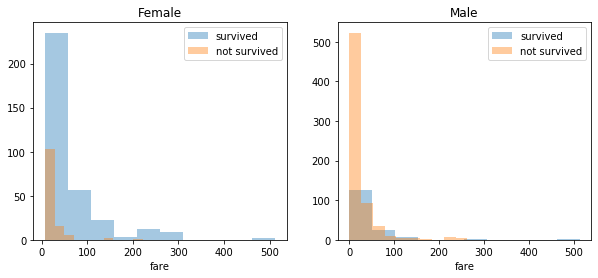

In [ ]:
# Fare, sex and survived

male = df[df['sex'] == 'male']
female = df[df['sex'] == 'female']

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

ax = sb.distplot(female[female['survived'] == 1].fare.dropna(), bins = 10, label = 'survived', ax = axes[0], kde = False)
ax = sb.distplot(female[female['survived'] == 0].fare.dropna(), bins = 10, label = 'not survived', ax = axes[0], kde = False)

ax.legend()
ax.set_title('Female')

ax = sb.distplot(male[male['survived'] == 1].fare.dropna(), bins = 10, label = 'survived', ax = axes[1], kde = False)
ax = sb.distplot(male[male['survived'] == 0].fare.dropna(), bins = 10, label = 'not survived', ax = axes[1], kde = False)

ax.legend()
ax.set_title('Male')

fig.savefig('faresexsurv.png', dpi = 400)

C:\Users\Wildan-PC\Anaconda3\lib\site-packages\seaborn\axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


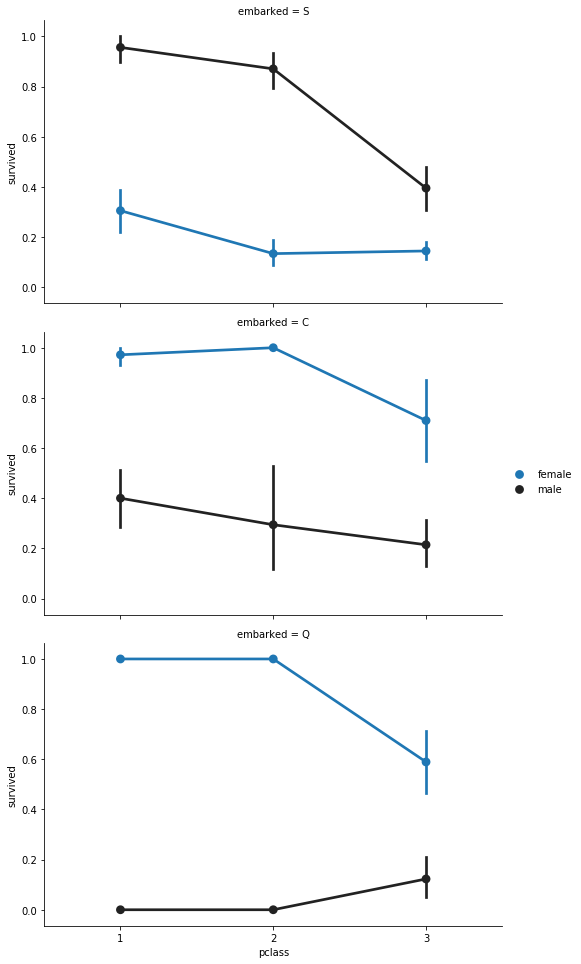

In [ ]:
FacetGrid = sb.FacetGrid(df, row='embarked', size=4.5, aspect=1.6)
FacetGrid.map(sb.pointplot, 'pclass', 'survived', 'sex', palette=None,  order=None, hue_order=None )
FacetGrid.add_legend()

FacetGrid.savefig('embarked.png', dpi = 400)

##  Features Engineering
___

In [ ]:
df = pd.read_excel('titanic3.xls')

# Dropping unnecessary columns
df = df.drop(columns = ['ticket','boat','home.dest','cabin','body'])
df.head(5)

,pclass,survived,name,sex,age,sibsp,parch,fare,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,211.3375,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,151.5500,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,151.5500,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,151.5500,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,151.5500,S


#### Name

In [ ]:
# Mengekstrak title untuk setiap nama

CONSTANTS.titles.add('jonkheer','don','dona','major')

df['title'] = [HumanName(name).title for name in df['name']]
titles = list(set(df['title'].values))

# Menghitung survival rate untuk setiap title sehingga dapat ditentukan prioritas penyelamatan setiap title

surv_rate = []
priority = []
for title in titles:
    alive = 0
    for i in range(len(df)):
        if df['title'][i] == title and df['survived'][i] == 1:
            alive = alive + 1
    survival_rate = alive/len(df[df['title']==title])
    surv_rate.append(survival_rate)
    print('Survival rate of', title,':',survival_rate)

surv_dict = dict()

for i in range(len(titles)):
    surv_dict[titles[i]] = surv_rate[i]

# Mendefinisikan attributes baru

df['mother'] = [1 if df['title'][i] == 'Mrs.' and df['parch'][i] > 0 else 0 for i in range(len(df))]
df['priority'] = [0 if surv_dict[title] < 0.2 else 1 if surv_dict[title] < 0.4 else 2 if surv_dict[title] < 0.6 else 3 if surv_dict[title] < 0.8 else 4 for title in df['title']]
df['respect'] = [1 if df['title'][i] in ['Dr.', 'Sir.', 'Lady.', 'Rev.', 'Don.', 'Dona.', 'Jonkheer', 'the Countess of.', 'Major.', 'Col.'] else 0 for i in range(len(df))]

df.head(5)

Survival rate of Mr. : 0.16248348745046234
Survival rate of Mrs. : 0.7868020304568528
Survival rate of Major. : 0.5
Survival rate of Lady. : 1.0
Survival rate of Dona. : 1.0
Survival rate of Jonkheer. : 0.0
Survival rate of Ms. : 0.5
Survival rate of Capt. : 0.0
Survival rate of the Countess. of : 1.0
Survival rate of Mme. : 1.0
Survival rate of Don. : 0.0
Survival rate of Mlle. : 1.0
Survival rate of Master. : 0.5081967213114754
Survival rate of Miss. : 0.676923076923077
Survival rate of Dr. : 0.5
Survival rate of Sir. : 1.0
Survival rate of Rev. : 0.0
Survival rate of Col. : 0.5


,pclass,survived,name,sex,age,sibsp,parch,fare,embarked,title,mother,priority,respect
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,211.3375,S,Miss.,0,3,0
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,151.5500,S,Master.,0,2,0
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,151.5500,S,Miss.,0,3,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,151.5500,S,Mr.,0,0,0
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,151.5500,S,Mrs.,1,3,0


#### Sex

In [ ]:
df['sex'] = df['sex'].replace(['female', 'male'],[1,0])
df.head(5)

,pclass,survived,name,sex,age,sibsp,parch,fare,embarked,title,mother,priority,respect
0,1,1,"Allen, Miss. Elisabeth Walton",1,29.0000,0,0,211.3375,S,Miss.,0,3,0
1,1,1,"Allison, Master. Hudson Trevor",0,0.9167,1,2,151.5500,S,Master.,0,2,0
2,1,0,"Allison, Miss. Helen Loraine",1,2.0000,1,2,151.5500,S,Miss.,0,3,0
3,1,0,"Allison, Mr. Hudson Joshua Creighton",0,30.0000,1,2,151.5500,S,Mr.,0,0,0
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,25.0000,1,2,151.5500,S,Mrs.,1,3,0


#### Age

In [ ]:
# Fill missing age value with age average of each name group

age_mean = df.loc[:,['name','age']].groupby('name').mean()
age_mean = list(age_mean['age'])
titles = list(set(df['name'].values))
titles.sort()
ave = dict(zip(titles, age_mean))

df['age'] = df['age'].fillna(0)
for i in range(len(df['age'])):
    if df['age'][i] == 0:
        df['age'][i] == ave[df['name'][i]]

# Age classification

df['age'] = ['children' if df['age'][i] < 15 else 'youth' if df['age'][i] < 25 else 'adult' if df['age'][i] < 65 else 'senior' for i in range(len(df['age']))]
df['age'] = df['age'].replace(['children', 'youth', 'adult', 'senior'],[4,3,2,1])
df['children'] = [1 if df['age'][i] == 'children' else 0 for i in range(len(df))]


# Menambahkan bobot age yang dikombinasikan dengan kelas

df['age_class'] = df['age']*df['pclass']

df = df.drop(columns = ['name', 'title'])

df.head(5)

,pclass,survived,sex,age,sibsp,parch,fare,embarked,mother,priority,respect,children,age_class
0,1,1,1,2,0,0,211.3375,S,0,3,0,0,2
1,1,1,0,4,1,2,151.5500,S,0,2,0,0,4
2,1,0,1,4,1,2,151.5500,S,0,3,0,0,4
3,1,0,0,2,1,2,151.5500,S,0,0,0,0,2
4,1,0,1,2,1,2,151.5500,S,1,3,0,0,2


#### Fare

In [ ]:
# Kita bisa menggolongkan fare kedalam 4 kelas
# Untuk missing value idenya adalah mengisi missing value dengan rata-rata missing value dari kelas yang sama

def fare_category(fare):
    tiket = "-"
    if fare < 7.9:
        tiket = "Cheap"
    else :
        if fare < 14.5:
            tiket = "Normal"
        else :
            if fare <31.3:
                tiket = "High"
            else :
                tiket = "Expensive"
    return tiket

fr_mean = df.groupby('pclass')['fare'].mean()
fr_mean = list(fr_mean)
fr_mean_t = list(set(df['pclass'].values))
fr_mean_t.sort(reverse = True)

join = dict(zip(fr_mean_t, fr_mean))

df['fare'] = df['fare'].fillna(0)
for i in range(len(df['fare'])):
    if df['fare'][i] == 0:
        df['fare'][i] == join[df['pclass'][i]]

df['fare_category'] = df.apply(lambda row: fare_category(row[6]), axis=1)
df['fare_category'] = df['fare_category'].replace(['Cheap', 'Normal', 'High', 'Expensive'],[1,2,3,4])

df = df.drop(columns = ['fare'])
df.head(5)

,pclass,survived,sex,age,sibsp,parch,embarked,mother,priority,respect,children,age_class,fare_category
0,1,1,1,2,0,0,S,0,3,0,0,2,4
1,1,1,0,4,1,2,S,0,2,0,0,4,4
2,1,0,1,4,1,2,S,0,3,0,0,4,4
3,1,0,0,2,1,2,S,0,0,0,0,2,4
4,1,0,1,2,1,2,S,1,3,0,0,2,4


#### Sibsp and Parch

In [ ]:
# Mendefinisikan apakah penumpang bepergian sendiri atau tidak

df['together'] = [1 if df['parch'][i] > 0 or df['sibsp'][i] > 0 else 0 for i in range(len(df))]

df.head(5)

,pclass,survived,sex,age,sibsp,parch,embarked,mother,priority,respect,children,age_class,fare_category,together
0,1,1,1,2,0,0,S,0,3,0,0,2,4,0
1,1,1,0,4,1,2,S,0,2,0,0,4,4,1
2,1,0,1,4,1,2,S,0,3,0,0,4,4,1
3,1,0,0,2,1,2,S,0,0,0,0,2,4,1
4,1,0,1,2,1,2,S,1,3,0,0,2,4,1


#### Embarked

In [ ]:
#df = df.drop(columns = ['embarked'])

df['embarked'] = df['embarked'].fillna('S')

In [ ]:
# Mengubah nilai embarked kedalam bentuk numerik

df['embarked'] = df['embarked'].replace(['S', 'C', 'Q'],[0,1,2])
df_encode = df
df_encode.head(5)

,pclass,survived,sex,age,sibsp,parch,embarked,mother,priority,respect,children,age_class,fare_category,together
0,1,1,1,2,0,0,0,0,3,0,0,2,4,0
1,1,1,0,4,1,2,0,0,2,0,0,4,4,1
2,1,0,1,4,1,2,0,0,3,0,0,4,4,1
3,1,0,0,2,1,2,0,0,0,0,0,2,4,1
4,1,0,1,2,1,2,0,1,3,0,0,2,4,1


In [ ]:
# Melihat persentase missing value setiap attribut

print('Persentase missing value untuk attribute:')
for i in range(len(df_encode.columns)):
    p = (df_encode[df_encode[df_encode.columns[i]].isnull()].shape[0]/len(df_encode))*100 
    print(i+1, df_encode.columns[i], ':', '%.3f' % p)

Persentase missing value untuk attribute:
1 pclass : 0.000
2 survived : 0.000
3 sex : 0.000
4 age : 0.000
5 sibsp : 0.000
6 parch : 0.000
7 embarked : 0.000
8 mother : 0.000
9 priority : 0.000
10 respect : 0.000
11 children : 0.000
12 age_class : 0.000
13 fare_category : 0.000
14 together : 0.000


In [ ]:
# Melihat survival rate setiap attribut

columnsTitanic = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'mother', 'priority', 'respect', 'children', 'age_class', 'fare_category', 'together']
df_survive = df[df['survived']==1]
for col in columnsTitanic :
    print("Survive rate of ", col , " Attribute :")
    dict_class   = dict(df[col].value_counts())
    dict_survive = dict(df_survive[col].value_counts())
    for x in dict_class:
        survive_count = 0
        if x in dict_survive :
            survive_count = dict_survive[x]
        else :
            survive_count = 0
        #textfrom = ""
        if len(str(x)) > 11 :
            textsurvive = " survive "
        else :
            textsurvive = "\t survive "
        if len(str(x)) < 7 :
            textfrom = "\t : from "
        else :
            textfrom = " : from "
        print(x, textfrom, dict_class[x], textsurvive, survive_count, "\t Rate : ", '{:.4f}'.format(survive_count/dict_class[x]))
    print("------------------------------")

Survive rate of  pclass  Attribute :
3 	 : from  709 	 survive  181 	 Rate :  0.2553
1 	 : from  323 	 survive  200 	 Rate :  0.6192
2 	 : from  277 	 survive  119 	 Rate :  0.4296
------------------------------
Survive rate of  sex  Attribute :
0 	 : from  843 	 survive  161 	 Rate :  0.1910
1 	 : from  466 	 survive  339 	 Rate :  0.7275
------------------------------
Survive rate of  age  Attribute :
2 	 : from  624 	 survive  248 	 Rate :  0.3974
4 	 : from  372 	 survive  134 	 Rate :  0.3602
3 	 : from  300 	 survive  116 	 Rate :  0.3867
1 	 : from  13 	 survive  2 	 Rate :  0.1538
------------------------------
Survive rate of  sibsp  Attribute :
0 	 : from  891 	 survive  309 	 Rate :  0.3468
1 	 : from  319 	 survive  163 	 Rate :  0.5110
2 	 : from  42 	 survive  19 	 Rate :  0.4524
4 	 : from  22 	 survive  3 	 Rate :  0.1364
3 	 : from  20 	 survive  6 	 Rate :  0.3000
8 	 : from  9 	 survive  0 	 Rate :  0.0000
5 	 : from  6 	 survive  0 	 Rate :  0.0000
-----------------

## Modeling
---

#### Split data train dan test

In [ ]:
# Membagi kedalam variable bebas dan terikat
# Dari 100% dibagi dulu jadi training dan testing
# Pembagian testing ini biasanya antara 10-20% bisa digunakan t-test untuk menguji si 10-20% ini sudah sesuai dengan sampel atau belum
# Nah si 80-90% data yang lain ini digunakan untuk modeling dan tunning parameters
# Tau hasilnya overfit atau ga itu kalau hasil modeling dan tunning pakai 80-90% data itu mirip dengan hasil pakai 10-20%

Y = df_encode['survived'].values
X = df_encode.drop(columns = ['survived']).values

In [ ]:
# Memisahkan antara train dan test dataset

xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size = 0.1, random_state = 0)

# Oversampling train

ros = RandomOverSampler()
xtrain, ytrain = ros.fit_resample(xtrain, ytrain)

clc.Counter(ytrain)

#### Model secara umum

In [ ]:
# Pada tahap ini, didefinisikan model untuk prediksi awal

models = { 'logistic_regression' : LogisticRegression(solver = 'lbfgs'), 'svc' : SVC(gamma = 'auto'), 'tree' : DecisionTreeClassifier(), 'forest' : RandomForestClassifier(n_estimators = 10) } 
modname = ['logistic_regression', 'svc', 'tree', 'forest']

def modclass(x, y, nfold, mod):
    model = models[mod]
    scores = cross_val_score(model, x, y, cv = nfold, scoring = "accuracy")
    
    print("Hasil perhitungan untuk model", mod, ': \n')
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard Deviation:", scores.std(), '\n')

for i in range(len(modname)):
    modclass(xtrain, ytrain, 10, modname[i])

C:\Users\Wildan-PC\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:947: ConvergenceWarning: lbfgs failed to converge. Increase the number of iterations.
  "of iterations.", ConvergenceWarning)
C:\Users\Wildan-PC\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:947: ConvergenceWarning: lbfgs failed to converge. Increase the number of iterations.
  "of iterations.", ConvergenceWarning)
C:\Users\Wildan-PC\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:947: ConvergenceWarning: lbfgs failed to converge. Increase the number of iterations.
  "of iterations.", ConvergenceWarning)


Hasil perhitungan untuk model logistic_regression : 

Scores: [0.82352941 0.77310924 0.83898305 0.80508475 0.81355932 0.83898305
 0.76068376 0.79487179 0.86324786 0.81196581]
Mean: 0.8124018055722942
Standard Deviation: 0.029501360242294675 

Hasil perhitungan untuk model svc : 

Scores: [0.84033613 0.78991597 0.84745763 0.8220339  0.83050847 0.83050847
 0.75213675 0.78632479 0.85470085 0.82051282]
Mean: 0.8174435789091821
Standard Deviation: 0.030291948416455022 

Hasil perhitungan untuk model tree : 

Scores: [0.78991597 0.76470588 0.79661017 0.75423729 0.8220339  0.78813559
 0.76068376 0.76923077 0.86324786 0.77777778]
Mean: 0.7886578968832209
Standard Deviation: 0.031272247466586474 

Hasil perhitungan untuk model forest : 

Scores: [0.80672269 0.74789916 0.79661017 0.79661017 0.81355932 0.78813559
 0.74358974 0.76068376 0.84615385 0.82051282]
Mean: 0.7920477273916955
Standard Deviation: 0.031230984618167954 



### In-depth Modeling
---
#### SVM Classifier

In [ ]:
sv = SVC(gamma = 'auto')
scoresvi = cross_val_score(sv, xtrain, ytrain, cv = 10, scoring = "accuracy")

print("Scores:", scoresvi)
print("Mean:", scoresvi.mean())
print("Standard Deviation:", scoresvi.std())

Scores: [0.84033613 0.78991597 0.84745763 0.8220339  0.83050847 0.83050847
 0.75213675 0.78632479 0.85470085 0.82051282]
Mean: 0.8174435789091821
Standard Deviation: 0.030291948416455022


In [ ]:
tuned_parameters = [{'kernel': ['rbf'], 'gamma': [1e-2, 1e-3, 1e-4, 1e-5],
                     'C': [0.001, 0.10, 0.1, 10, 25, 50, 100, 1000]},
                    {'kernel': ['sigmoid'], 'gamma': [1e-2, 1e-3, 1e-4, 1e-5],
                     'C': [0.001, 0.10, 0.1, 10, 25, 50, 100, 1000]},
                    {'kernel': ['linear'], 'C': [0.001, 0.10, 0.1, 10, 25, 50, 100, 1000]}
                   ]

clfs = GridSearchCV(SVC(C=1), tuned_parameters, cv = 10,
                       scoring = 'accuracy')
clfs.fit(xtrain, ytrain)

clfs.best_params_

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

In [ ]:
# Melihat akurasi model dengan parameter yang memberikan nilai maksimal

sv_tun = SVC(kernel = 'rbf', C = 10, gamma = 0.01)

scoresvf = cross_val_score(sv_tun, xtrain, ytrain, cv = 10, scoring = "accuracy")

print("Scores:", scoresvf)
print("Mean:", scoresvf.mean())
print("Standard Deviation:", scoresvf.std())

Scores: [0.84033613 0.76470588 0.83898305 0.8220339  0.81355932 0.83050847
 0.76923077 0.8034188  0.83760684 0.82905983]
Mean: 0.8149443001885673
Standard Deviation: 0.026412747383606633


Accuracy score: 0.8015267175572519
Precision score: 0.7391304347826086
Recall score: 0.7083333333333334
f1 score: 0.723404255319149
MAE test score: 0.1984732824427481
RMSE test score: 0.44550340340198086
[[71 12]
 [14 34]]


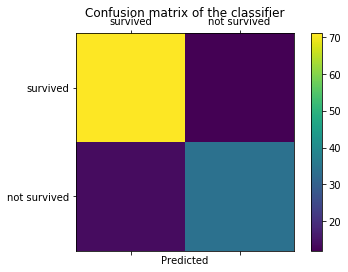

In [ ]:
# Menguji data test menggunakan model yang sudah didefinisikan

sv_tun.fit(xtrain, ytrain)
ypred = sv_tun.predict(xtest)

print("Accuracy score:", sk.metrics.accuracy_score(ytest, ypred))
print("Precision score:", sk.metrics.precision_score(ytest, ypred))
print("Recall score:", sk.metrics.recall_score(ytest, ypred))
print("f1 score:", sk.metrics.f1_score(ytest, ypred))
print("MAE test score:", sk.metrics.mean_absolute_error(ytest, ypred))
print("RMSE test score:", np.sqrt(sk.metrics.mean_squared_error(ytest, ypred)))

# Confusion matrix

labels = ['survived', 'not survived']
cm = confusion_matrix(ytest, ypred)
print(cm)

fcf = plt.figure()
ax = fcf.add_subplot(111)
cax = ax.matshow(cm)
plt.title('Confusion matrix of the classifier')
fcf.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')

fcf.savefig('confusion.png', dpi = 400)

#### Random forest classifier

forest = RandomForestClassifier(n_estimators = 10) 
scoresi = cross_val_score(forest, xtrain, ytrain, cv = 10, scoring = "accuracy")

print("Scores:", scoresi)
print("Mean:", scoresi.mean())
print("Standard Deviation:", scoresi.std())

#### Hyperparameters tunning

# Ini contoh tunning untuk random forest classifier

param = { "criterion" : ["gini", "entropy"], "min_samples_leaf" : [1, 3, 5, 10, 25], "min_samples_split" : [2, 4, 10, 12, 16, 18], "n_estimators": [100, 200, 400, 600, 1000]}\

clf = GridSearchCV(estimator = forest, param_grid = param, cv = 10, n_jobs = -1)

clf.fit(xtrain, ytrain)

clf.best_params_

# Mencoba parameter yang sudah ditunning

forest_tun = RandomForestClassifier(criterion = 'entropy', min_samples_leaf = 3, min_samples_split = 2, n_estimators = 400) 
forest_tun.fit(xtrain, ytrain)

acc_fr = round(forest_tun.score(xtrain, ytrain) * 100, 2)

scoresf = cross_val_score(forest_tun, xtrain, ytrain, cv = 10, scoring = "accuracy")

print(acc_fr)
print("Scores:", scoresf)
print("Mean:", scoresf.mean())
print("Standard Deviation:", scoresf.std())

# Menguji test menggunakan model yang sudah didefinisikan

ypred = forest_tun.predict(xtest)
acc_test = round(accuracy_score(ytest, ypred) * 100, 2)
acc_test